# Experiment: 2D cond 1D

dim(x)=1, dim(y)=1 — comparing LGD vs LGD-CM.

In [173]:
# ============================================================
# CONFIG — only this cell changes between notebooks
# Structure:
#   simulations/src/        ← all .py modules
#   simulations/notebooks/  ← this notebook
#   simulations/params/     ← canonical GMM parameters (shared, load first)
#   simulations/checkpoints/
#   simulations/results/
# ============================================================
EXPERIMENT_NAME   = "2D_cond_1D"
GLOBAL_SEED       = 42
FORCE_RETRAIN     = False

BASE_DIR          = "/content/conditional-matching-paper/simulations"
PARAMS_DIR        = f"{BASE_DIR}/params"
CHECKPOINT_DIR    = f"{BASE_DIR}/checkpoints/{EXPERIMENT_NAME}"
RESULTS_DIR       = f"{BASE_DIR}/results/{EXPERIMENT_NAME}"

# Architecture — Diffusion models
NBLOCKS           = 3
NUNITS            = 128

# Architecture — Consistency Model (separate so it can be scaled independently)
NBLOCKS_CM        = 3
NUNITS_CM         = 128

# Training — Diffusion
NEPOCHS           = 20_000
BATCH_SIZE        = 1_024

# Training — Consistency Model
NEPOCHS_CM        = 20_000
BATCH_SIZE_CM     = 1_024

# Diffusion
DIFFUSION_STEPS   = 100

# Optimization
N_ATTEMP_OPTIM              = 25
NSAMPLES_IN_OPTIM_FOR_MMD   = 250
NUM_X_T_LGD                 = 3
NUM_X_T_LGD_CM              = 3

# GMM dimensions
CONDITION_ON      = 1   # dim(x)=1, dim(y)=1

In [15]:
!pip install flow_matching -q
!pip install POT -q

In [16]:
import os, sys
from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get('HF')
if hf_token:
    login(token=hf_token)
else:
    login()

if 'google.colab' in str(get_ipython()):
    import getpass
    !pip install -q diffusers transformers accelerate xformers
    !pip install -q scikit-learn matplotlib Pillow

    github_token = userdata.get('GITHUB')
    token = github_token if github_token else getpass.getpass("Enter your GitHub personal access token: ")

    repo_url  = f"https://{token}@github.com/orineo1/conditional-matching-paper.git"
    repo_name = "conditional-matching-paper"
    branch    = "adding-simu-compare"

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        print(f"Repo '{repo_name}' already cloned — pulling latest...")
        !cd {repo_name} && git pull

    !cd {repo_name} && git checkout {branch}

# ── point Python at simulations/src where all .py modules live ──
src_path = f"/content/{repo_name}/simulations/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Branch: {branch}")
print(f"src path on sys.path: {src_path}")

Repo 'conditional-matching-paper' already cloned — pulling latest...
Already up to date.
error: pathspec 'adding-simu-compare' did not match any file(s) known to git
Branch: adding-simu-compare
src path on sys.path: /content/conditional-matching-paper/simulations/src


In [17]:
import os, sys, time, json
import importlib
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from tqdm import trange

import Diffusion
import LossFunctions
import ConsistencyModels
import dist_utils
import Optimization
import experiment_utils
from ConsistencyModels import ConsistencyModeliCT
import evalModels

for mod in [Diffusion, LossFunctions, ConsistencyModels,
            dist_utils, Optimization, experiment_utils]:
    importlib.reload(mod)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)
os.makedirs(PARAMS_DIR,     exist_ok=True)
print("Imports done.")

Imports done.


In [18]:
env_info = experiment_utils.get_environment_info()
experiment_utils.print_environment_info(env_info)

ENVIRONMENT INFO
  timestamp: 2026-04-20T06:08:31.303539
  torch_version: 2.10.0+cu128
  cuda_available: True
  cuda_version: 12.8
  device_name: Tesla T4
  packages:
    torch: 2.10.0+cu128
    numpy: 2.0.2
    flow_matching: 1.0.10
    POT: 0.9.6.post1
    matplotlib: 3.10.0
    pandas: 2.2.2
    tqdm: 4.67.3


In [19]:
experiment_utils.set_global_seed(GLOBAL_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

[Seed] All random seeds set to 42
Using device: cuda


## GMM Parameters

In [20]:
# ============================================================
# GMM PARAMETERS
# Priority:
#   1. Load from PARAMS_DIR  (shared across runs, committed to repo)
#   2. Load from RESULTS_DIR (fallback from a previous run)
#   3. Generate fresh and save to both dirs
#
# To force regeneration: set FORCE_REGENERATE_PARAMS = True
# ============================================================
FORCE_REGENERATE_PARAMS = False

def _load_params():
    """Try PARAMS_DIR first, then RESULTS_DIR."""
    loaded = experiment_utils.load_gmm_params(PARAMS_DIR, EXPERIMENT_NAME)
    if loaded is not None:
        print(f"[GMM] Loaded from PARAMS_DIR: {PARAMS_DIR}")
        return loaded
    loaded = experiment_utils.load_gmm_params(RESULTS_DIR, EXPERIMENT_NAME)
    if loaded is not None:
        print(f"[GMM] Loaded from RESULTS_DIR: {RESULTS_DIR}")
        return loaded
    return None

loaded = None if FORCE_REGENERATE_PARAMS else _load_params()

if loaded is not None:
    mu_list, Sigma_list, alpha, mog_means, mog_variances, weights, x_star = loaded
    mu_list    = [mu.float() for mu in mu_list]
    Sigma_list = [cov.float() for cov in Sigma_list]
    alpha      = alpha.float()
else:
    print("[GMM] Generating fresh parameters...")
    experiment_utils.set_global_seed(GLOBAL_SEED)   # seed generation for reproducibility
    mu_list = [
        torch.tensor([-5,  5], dtype=torch.float64),
        torch.tensor([-5, -5], dtype=torch.float64),
        torch.tensor([ 5,  3], dtype=torch.float64),
        torch.tensor([ 5, -1], dtype=torch.float64),
        torch.tensor([ 0, -3], dtype=torch.float64),
        torch.tensor([-2,  4], dtype=torch.float64),
        torch.tensor([-2, -3], dtype=torch.float64),
        torch.tensor([ 1,  2], dtype=torch.float64),
        torch.tensor([-8,  1], dtype=torch.float64),
        torch.tensor([ 7,  5], dtype=torch.float64),
        torch.tensor([ 0, -5], dtype=torch.float64),
    ]
    Sigma_list = [
        torch.tensor([[0.5000, 0.1950],
                      [0.1950, 0.2000]], dtype=torch.float64)
    ] * len(mu_list)
    alpha = torch.tensor([1 / len(mu_list)] * len(mu_list), dtype=torch.float64)

    mu_list    = [mu.float() for mu in mu_list]
    Sigma_list = [cov.float() for cov in Sigma_list]
    alpha      = alpha.float()

    x_star = torch.tensor([-5])
    mu_temp, Sigma_temp = dist_utils.compute_conditionals(mu_list, Sigma_list, x_star)
    temp_alpha          = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_star)
    mog_means, mog_variances, weights = dist_utils.filter_and_normalize(
        mu_temp, Sigma_temp, temp_alpha, threshold=0.01
    )

    # save to PARAMS_DIR (canonical, share across runs)
    experiment_utils.save_gmm_params(
        mu_list, Sigma_list, alpha,
        mog_means, mog_variances, weights, x_star,
        PARAMS_DIR, EXPERIMENT_NAME
    )

print(f"x_star = {x_star}")
print(f"Number of conditional modes after filtering: {len(mog_means)}")

[GMM] Parameters loaded from /content/conditional-matching-paper/simulations/params/2D_cond_1D_gmm_params.pt
[GMM] Loaded from PARAMS_DIR: /content/conditional-matching-paper/simulations/params
x_star = tensor([-5])
Number of conditional modes after filtering: 2


## Data

[Seed] All random seeds set to 42


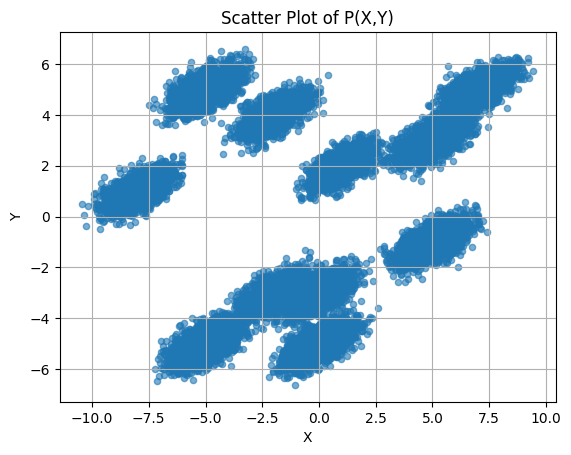

In [21]:
experiment_utils.set_global_seed(GLOBAL_SEED)
X = dist_utils.generate_mog_samples(25_000, mu_list, Sigma_list, alpha).float().to(device)
xh_cpu = X.detach().cpu().numpy()
plt.scatter(xh_cpu[:, 0], xh_cpu[:, 1], alpha=0.6, s=20)
plt.title("Scatter Plot of P(X,Y)")
plt.xlabel("X"); plt.ylabel("Y"); plt.grid(True); plt.show()

## Train Models

### Consistency Model — P(Y|X=x)

In [174]:
experiment_utils.set_global_seed(GLOBAL_SEED)

B, C      = X.shape
nfeatures = C - CONDITION_ON
data_generator_cm = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha
)

Cos_ConsistencyModeliCT = ConsistencyModeliCT(
    nfeatures=nfeatures, condition_on=CONDITION_ON,
    nunits=NUNITS_CM, depth=NBLOCKS_CM
)

_loaded_cm = experiment_utils.load_model_checkpoint(
    Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR,
    EXPERIMENT_NAME, GLOBAL_SEED, device
) if not FORCE_RETRAIN else False

if not _loaded_cm:
    experiment_utils.set_global_seed(GLOBAL_SEED)
    Cos_ConsistencyModeliCT.train_model(
        X=None, nepochs=NEPOCHS_CM, batch_size=BATCH_SIZE_CM,
        device=device, condition=CONDITION_ON,
        data_generator=data_generator_cm, use_improved_training=True
    )
    experiment_utils.save_model_checkpoint(
        Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR,
        EXPERIMENT_NAME, GLOBAL_SEED
    )

[Seed] All random seeds set to 42
[Checkpoint] No checkpoint found for CM at /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_CM_seed42.pt
[Seed] All random seeds set to 42


loss: 0.486211, mu: 0.0000, N: 161:  69%|██████▉   | 27538/40000 [03:48<01:43, 120.47it/s]


KeyboardInterrupt: 

### Diffusion — P(Y|X=x)

In [10]:
experiment_utils.set_global_seed(GLOBAL_SEED)

X_train   = dist_utils.generate_mog_samples(1_000, mu_list, Sigma_list, alpha).float().to(device)
nfeatures = X_train.shape[1]

data_generator_diff_cond = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha, kernel_func=None
)

model_cond = Diffusion.DiffusionModel(
    nfeatures=nfeatures, nblocks=NBLOCKS, nunits=NUNITS,
    condition=True, condition_on=CONDITION_ON,
    diffusion_steps=DIFFUSION_STEPS
)

_loaded_diff_cond = experiment_utils.load_model_checkpoint(
    model_cond, "Diffusion_cond", CHECKPOINT_DIR,
    EXPERIMENT_NAME, GLOBAL_SEED, device
) if not FORCE_RETRAIN else False

if not _loaded_diff_cond:
    experiment_utils.set_global_seed(GLOBAL_SEED)
    model_cond.train_model(
        None, data_generator=data_generator_diff_cond,
        nepochs=NEPOCHS, batch_size=BATCH_SIZE,
        condition_on=CONDITION_ON
    )
    experiment_utils.save_model_checkpoint(
        model_cond, "Diffusion_cond", CHECKPOINT_DIR,
        EXPERIMENT_NAME, GLOBAL_SEED
    )

[Seed] All random seeds set to 42
[Checkpoint] Diffusion_cond loaded from /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_cond_seed42.pt


### Diffusion — P(X=x)

In [11]:
experiment_utils.set_global_seed(GLOBAL_SEED)

data_generator_diff_uncond = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha,
    kernel_func=lambda X: X[:, :CONDITION_ON]
)

model_uncond = Diffusion.DiffusionModel(
    nfeatures=CONDITION_ON, nblocks=NBLOCKS, nunits=NUNITS,
    condition=False, diffusion_steps=DIFFUSION_STEPS
)

_loaded_diff_uncond = experiment_utils.load_model_checkpoint(
    model_uncond, "Diffusion_uncond", CHECKPOINT_DIR,
    EXPERIMENT_NAME, GLOBAL_SEED, device
) if not FORCE_RETRAIN else False

if not _loaded_diff_uncond:
    experiment_utils.set_global_seed(GLOBAL_SEED)
    model_uncond.train_model(
        None, data_generator=data_generator_diff_uncond,
        nepochs=NEPOCHS, batch_size=BATCH_SIZE,
        condition_on=CONDITION_ON
    )
    experiment_utils.save_model_checkpoint(
        model_uncond, "Diffusion_uncond", CHECKPOINT_DIR,
        EXPERIMENT_NAME, GLOBAL_SEED
    )

[Seed] All random seeds set to 42
[Checkpoint] Diffusion_uncond loaded from /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_uncond_seed42.pt


## Optimize

### LGD

In [ ]:
# NOTE: optimize_LGD call is untouched — only seed management added around it
best_x_t_LGD_list = []
l2_gmm_LGD_list   = []
l2_x_LGD_list     = []
lgd_times         = []
final_loss_LGD    = []

for i in trange(N_ATTEMP_OPTIM):
    run_seed = experiment_utils.set_run_seed(GLOBAL_SEED, i)

    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, model_cond, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=NSAMPLES_IN_OPTIM_FOR_MMD, loss="MMD", device=device,
        num_x_t=NUM_X_T_LGD
    )
    end_time = time.time()

    lgd_times.append(end_time - start_time)
    final_loss_LGD.append(final_loss)
    best_x_t_LGD_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(
        mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights
    )
    l2_x = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_list.append(l2_gmm)
    l2_x_LGD_list.append(l2_x)
    print(f"[{i+1}] seed={run_seed} | L2 GMM: {l2_gmm:.6f} | L2 to x*: {l2_x:.6f}")

  4%|▍         | 1/25 [02:06<50:46, 126.95s/it]

[1] seed=42 | L2 GMM: 0.543232 | L2 to x*: 153.880432


  8%|▊         | 2/25 [04:13<48:40, 126.96s/it]

[2] seed=43 | L2 GMM: 1.201885 | L2 to x*: 10.237726


 12%|█▏        | 3/25 [06:21<46:35, 127.08s/it]

...

[23] seed=64 | L2 GMM: 0.015921 | L2 to x*: 0.255826


 96%|█████████▌| 24/25 [50:47<02:07, 127.17s/it]

[24] seed=65 | L2 GMM: 0.008519 | L2 to x*: 0.186600


100%|██████████| 25/25 [52:54<00:00, 126.96s/it]

[25] seed=66 | L2 GMM: 0.793724 | L2 to x*: 9.955807


### LGD-CM

In [ ]:
# NOTE: optimize_LGD call is untouched — only seed management added around it
best_x_t_LGD_CM_list = []
l2_gmm_LGD_CM_list   = []
l2_x_LGD_CM_list     = []
lgd_cm_times         = []
final_loss_LGD_CM    = []

for i in trange(N_ATTEMP_OPTIM):
    run_seed = experiment_utils.set_run_seed(GLOBAL_SEED, i)

    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, Cos_ConsistencyModeliCT,
        mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=NSAMPLES_IN_OPTIM_FOR_MMD, loss="MMD", device=device,
        CM=True, FLAG=False, num_x_t=NUM_X_T_LGD_CM
    )
    end_time = time.time()

    lgd_cm_times.append(end_time - start_time)
    final_loss_LGD_CM.append(final_loss)
    best_x_t_LGD_CM_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(
        mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights
    )
    l2_x = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_CM_list.append(l2_gmm)
    l2_x_LGD_CM_list.append(l2_x)
    print(f"[{i+1}] seed={run_seed} | L2 GMM: {l2_gmm:.6f} | L2 to x*: {l2_x:.6f}")

  4%|▍         | 1/25 [00:10<04:19, 10.82s/it]

[1] seed=42 | L2 GMM: 0.019227 | L2 to x*: 0.281314


  8%|▊         | 2/25 [00:21<04:08, 10.81s/it]

[2] seed=43 | L2 GMM: 0.028320 | L2 to x*: 0.342427


 12%|█▏        | 3/25 [00:32<03:57, 10.81s/it]

...

[23] seed=64 | L2 GMM: 0.037969 | L2 to x*: 0.397760


 96%|█████████▌| 24/25 [04:16<00:10, 10.67s/it]

[24] seed=65 | L2 GMM: 0.031568 | L2 to x*: 0.361918


100%|██████████| 25/25 [04:27<00:00, 10.68s/it]

[25] seed=66 | L2 GMM: 0.028355 | L2 to x*: 0.342640


## Results

In [ ]:
rows = [
    experiment_utils.summary_row("LGD",    l2_gmm_LGD_list,    l2_x_LGD_list,    lgd_times),
    experiment_utils.summary_row("LGD-CM", l2_gmm_LGD_CM_list, l2_x_LGD_CM_list, lgd_cm_times),
]
df = pd.DataFrame(rows).set_index("Method")
display(df)

rows_top10 = [
    experiment_utils.top10_stats("LGD",    final_loss_LGD,    l2_gmm_LGD_list,    l2_x_LGD_list,    lgd_times),
    experiment_utils.top10_stats("LGD-CM", final_loss_LGD_CM, l2_gmm_LGD_CM_list, l2_x_LGD_CM_list, lgd_cm_times),
]
df_top10 = pd.DataFrame(rows_top10).set_index("Method")
display(df_top10)

,L2 GMM mean,L2 GMM std,L2 to x* mean,L2 to x* std,Time mean (s),Time std (s)
Method,,,,,,
LGD,0.2877,0.3970,26.3486,78.9805,126.92,0.35
LGD-CM,0.0301,0.0066,0.3514,0.0392,10.65,0.10


,Loss mean,Loss std,L2 GMM mean,L2 GMM std,L2 to x* mean,L2 to x* std,Time mean (s),Time std (s),Top-k selected
Method,,,,,,,,,
LGD,0.0057,0.0045,0.0091,0.0070,0.1686,0.0950,126.91,0.37,10
LGD-CM,0.0359,0.0037,0.0293,0.0060,0.3465,0.0365,10.61,0.09,10


In [ ]:
def to_python(val):
    if isinstance(val, torch.Tensor):
        return val.detach().cpu().tolist()
    if isinstance(val, np.ndarray):
        return val.tolist()
    if hasattr(val, "item"):
        return val.item()
    return val

results = {
    "experiment":  EXPERIMENT_NAME,
    "seed":        GLOBAL_SEED,
    "environment": env_info,
    "LGD": {
        "x_pred":     [to_python(x) for x in best_x_t_LGD_list],
        "final_loss": [to_python(l) for l in final_loss_LGD],
        "l2_gmm":     l2_gmm_LGD_list,
        "l2_x":       l2_x_LGD_list,
        "times":      lgd_times,
    },
    "LGD-CM": {
        "x_pred":     [to_python(x) for x in best_x_t_LGD_CM_list],
        "final_loss": [to_python(l) for l in final_loss_LGD_CM],
        "l2_gmm":     l2_gmm_LGD_CM_list,
        "l2_x":       l2_x_LGD_CM_list,
        "times":      lgd_cm_times,
    },
    "meta": {
        "n_attemp_optim":            N_ATTEMP_OPTIM,
        "nsamples_in_optim_for_mmd": NSAMPLES_IN_OPTIM_FOR_MMD,
        "x_star":                    to_python(x_star),
    },
}

path = os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_results_seed{GLOBAL_SEED}.json")
with open(path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved to {path}")

Results saved to /content/conditional-matching-paper/simulations/results/2D_cond_1D/2D_cond_1D_results_seed42.json


# CDMS: Sampling vs Analytical Q(x) across ζ values

In [177]:
BATCH_SIZE_CM=2*4096
NEPOCHS_CM=80_000

In [178]:
experiment_utils.set_global_seed(GLOBAL_SEED)

B, C      = X.shape
nfeatures = C - CONDITION_ON
data_generator_cm = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha
)

Cos_ConsistencyModeliCT = ConsistencyModeliCT(
    nfeatures=nfeatures, condition_on=CONDITION_ON,
    nunits=NUNITS_CM, depth=NBLOCKS_CM
)

_loaded_cm = experiment_utils.load_model_checkpoint(
    Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR,
    EXPERIMENT_NAME, GLOBAL_SEED, device
) if not FORCE_RETRAIN else False

if not _loaded_cm:
    experiment_utils.set_global_seed(GLOBAL_SEED)
    Cos_ConsistencyModeliCT.train_model(
        X=None, nepochs=NEPOCHS_CM, batch_size=BATCH_SIZE_CM,
        device=device, condition=CONDITION_ON,
        data_generator=data_generator_cm, use_improved_training=True
    )
    experiment_utils.save_model_checkpoint(
        Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR,
        EXPERIMENT_NAME, GLOBAL_SEED
    )

[Seed] All random seeds set to 42
[Checkpoint] No checkpoint found for CM at /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_CM_seed42.pt
[Seed] All random seeds set to 42


loss: 0.390980, mu: 0.0000, N: 1281: 100%|██████████| 80000/80000 [10:46<00:00, 123.69it/s]


[Checkpoint] CM saved to /content/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_CM_seed42.pt


In [179]:
def gmm_l2_diff(mu_p, Sigma_p, w_p, mu_q, Sigma_q, w_q):
    """
    Differentiable exact L2 distance between two GMMs.
    Keeps autograd graph intact — gradients flow back to mu_p inputs.

    Args:
        mu_p:    (K1, D) tensor
        Sigma_p: (K1, D, D) tensor
        w_p:     (K1,) tensor
        mu_q:    (K2, D) tensor
        Sigma_q: (K2, D, D) tensor
        w_q:     (K2,) tensor
    """
    # Ensure shapes are (K, D) and (K, D, D)
    if mu_p.dim() == 1:    mu_p    = mu_p.unsqueeze(0)
    if mu_q.dim() == 1:    mu_q    = mu_q.unsqueeze(0)
    if Sigma_p.dim() == 2: Sigma_p = Sigma_p.unsqueeze(0)
    if Sigma_q.dim() == 2: Sigma_q = Sigma_q.unsqueeze(0)

    D = mu_p.shape[-1]

    def gaussian_inner_product(m1, S1, w1, m2, S2, w2):
        diff  = m1.unsqueeze(1) - m2.unsqueeze(0)           # (K1, K2, D)
        S_sum = S1.unsqueeze(1) + S2.unsqueeze(0)           # (K1, K2, D, D)

        _, logdet = torch.linalg.slogdet(S_sum)             # (K1, K2)
        inv_S_sum = torch.linalg.inv(S_sum)                 # (K1, K2, D, D)
        quad      = torch.einsum('ijk,ijkl,ijl->ij',
                                 diff, inv_S_sum, diff)     # (K1, K2)

        log_vals    = -0.5 * (D * math.log(2 * math.pi) + logdet + quad)
        log_weights = (torch.log(w1).unsqueeze(1) +
                       torch.log(w2).unsqueeze(0))          # (K1, K2)
        return torch.exp(log_weights + log_vals).sum()

    pp = gaussian_inner_product(mu_p, Sigma_p, w_p, mu_p, Sigma_p, w_p)
    qq = gaussian_inner_product(mu_q, Sigma_q, w_q, mu_q, Sigma_q, w_q)
    pq = gaussian_inner_product(mu_p, Sigma_p, w_p, mu_q, Sigma_q, w_q)

    return pp - 2 * pq + qq


def compute_l2_gmm_loss(x0_sample, mu_list, Sigma_list, alpha,
                        mog_means, mog_variances, weights, device):
    """
    Compute differentiable GMM L2 loss between P(Y|X=x0_sample) and G(Y).
    Gradient flows back through x0_sample -> x_t.

    Args:
        x0_sample:     (1, nfeatures) tensor, requires_grad, on device
        mu_list:       list of (D,) tensors — joint GMM means
        Sigma_list:    list of (D, D) tensors — joint GMM covariances
        alpha:         (K,) tensor — joint GMM weights
        mog_means:     (K2, 1, D_y) tensor — target conditional means
        mog_variances: (K2, 1, D_y, D_y) tensor — target conditional covariances
        weights:       (K2,) tensor — target conditional weights
        device:        torch device
    """
    # compute_conditionals / compute_alpha work on CPU with float tensors
    x0_cpu = x0_sample.view(-1).cpu()

    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x0_cpu)
    w_pred              = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x0_cpu)

    # mu_pred:    (K1, D_y, 1)  ->  squeeze to (K1, D_y)
    # Sigma_pred: (K1, D_y, D_y)
    mu_pred_d    = mu_pred.squeeze(-1).to(device)      # (K1, D_y)
    Sigma_pred_d = Sigma_pred.to(device)               # (K1, D_y, D_y)
    w_pred_d     = w_pred.to(device)                   # (K1,)

    # target G — squeeze out any extra dims
    mog_means_d  = mog_means.squeeze(1).to(device)     # (K2, D_y)
    mog_vars_d   = mog_variances.squeeze(1).to(device) # (K2, D_y, D_y)
    weights_d    = weights.to(device)                  # (K2,)

    return gmm_l2_diff(mu_pred_d, Sigma_pred_d, w_pred_d,
                       mog_means_d, mog_vars_d, weights_d)

In [180]:
def optimize_LGD(model_uncond, model_cond, mog_means, mog_variances, weights, mu_list, Sigma_list, alpha,
                 nsamples=250, num_x_t=3, loss="MMD", CM=False, device="cuda", FLAG=False,
                 zeta=1.0):

    mmd_loss = MMDLoss(kernel=RBF())
    best_mmd_loss = float("inf")
    best_x0_sample = None

    # x_t = torch.zeros(model_uncond.nfeatures, device=device, requires_grad=True)
    x_t = torch.randn((1, model_uncond.nfeatures), device=device, requires_grad=True)

    x_t = x_t.unsqueeze(0)
    pbar = tqdm(range(model_uncond.diffusion_steps - 1, 0, -1)) if FLAG else range(model_uncond.diffusion_steps - 1, 0, -1)

    for t in pbar:
        x_t = x_t.detach().clone().requires_grad_(True)

        optimizer = optim.Adam([x_t], lr=0.05)
        optimizer.zero_grad()

        x_t_minus_1, pred_x0 = model_uncond.sample_ddim_step(x_t, t, condition_x=None, device=device, eta=0.0)
        current_var = model_uncond.betas[t].to(device)
        r_t = current_var / torch.sqrt(1 + current_var ** 2)
        log_mean_exp_loss = torch.tensor([0])

        if zeta == 0.0:
            with torch.no_grad():
                x_t = x_t_minus_1.detach().clone()
            continue

        losses = []
        for j in range(num_x_t):
            x0_sample = pred_x0 + r_t * torch.randn_like(pred_x0)
            if loss == "L2_GMM":
                loss_val = compute_l2_gmm_loss(
                    x0_sample, mu_list, Sigma_list, alpha,
                    mog_means, mog_variances, weights, device
                )
            else:
                condition = x0_sample.view(1, -1).repeat(nsamples, 1)
                target_samples, _, _ = model_cond.sample(nsamples=nsamples, condition_x=condition, device=device)
                if not CM:
                    target_samples = target_samples[:, model_cond.condition_on:]
                mog_samples = generate_mog_samples_not_differentiable(nsamples, mog_means, mog_variances, weights)
                loss_val = mmd_loss(target_samples, mog_samples)

            losses.append(-loss_val)

            if FLAG:
                pbar.set_description(f"Step {t} | x_t:{x_t} | x0_sample:{x0_sample} | loss_val:{loss_val} | log_mean_exp_loss: {log_mean_exp_loss.item():.4f}")

            if loss_val.item() < best_mmd_loss:
                best_mmd_loss = loss_val.item()
                best_x0_sample = x0_sample.detach().clone()

        log_mean_exp_loss = -torch.logsumexp(torch.stack(losses), dim=0) + math.log(num_x_t)
        log_mean_exp_loss.backward()

        grad = x_t.grad.clone()
        grad = torch.clamp(grad, min=-0.25, max=.25)

        with torch.no_grad():
            lr = 0.05
            noise = torch.randn_like(x_t) * math.sqrt(2 * lr)
            x_t = x_t_minus_1.detach().clone() - (zeta * grad) + noise

    # Final loss evaluation
    condition = x_t.view(1, -1).repeat(nsamples, 1)
    target_samples, _, _ = model_cond.sample(nsamples=nsamples, condition_x=condition, device=device)
    if not CM:
        target_samples = target_samples[:, model_cond.condition_on:]
    mog_samples = generate_mog_samples_not_differentiable(nsamples, mog_means, mog_variances, weights)
    final_loss = mmd_loss(target_samples, mog_samples)

    x_t_final = x_t.detach().clone()
    del x_t, condition, target_samples, mog_samples
    torch.cuda.empty_cache() if device == "cuda" else None

    return x_t_final, x_t_final, final_loss.detach()

Precomputing P(x) on grid...
Precomputing L(x) [GMM L2] on grid...


100%|██████████| 500/500 [00:16<00:00, 30.05it/s]


In [214]:
ZETA_VALUES = [0.0, 1.0,2.,4.,8.,16.]

analytical_Q = {}
for zeta in ZETA_VALUES:
    q_unnorm           = px_grid * np.exp(-zeta * lx_grid)
    Z                  = np.trapz(q_unnorm, x_grid)
    analytical_Q[zeta] = q_unnorm / Z


/tmp/ipykernel_944/2215071465.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z                  = np.trapz(q_unnorm, x_grid)


In [182]:

from scipy.stats import gaussian_kde

N_CDMS_SAMPLES = 100

cdms_samples = {}

for zeta in ZETA_VALUES:
    print(f"\n[CDMS] Sampling β = {zeta} ...")
    samples = []
    for i in trange(N_CDMS_SAMPLES):
        experiment_utils.set_run_seed(GLOBAL_SEED, i)
        x_pred, _, _ = optimize_LGD(
            model_uncond, Cos_ConsistencyModeliCT,
            mog_means, mog_variances, weights,
            mu_list, Sigma_list, alpha,
            nsamples=NSAMPLES_IN_OPTIM_FOR_MMD,
            loss="MMD", device=device,
            CM=True, FLAG=False,
            num_x_t=NUM_X_T_LGD_CM,
            zeta=zeta
        )
        print(x_pred)
        samples.append(x_pred.float().view(-1).cpu()[0].item())
    cdms_samples[zeta] = np.array(samples)
    print(f"   mean={np.mean(samples):.3f} | std={np.std(samples):.3f}")

/tmp/ipykernel_944/191019990.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z                  = np.trapz(q_unnorm, x_grid)



[CDMS] Sampling β = 0.0 ...


  1%|          | 1/100 [00:00<00:43,  2.26it/s]

tensor([[[0.2243]]], device='cuda:0')


  2%|▏         | 2/100 [00:00<00:34,  2.88it/s]

...

tensor([[[-3.8154]]], device='cuda:0')


 99%|█████████▉| 99/100 [21:31<00:13, 13.20s/it]

tensor([[[-4.1992]]], device='cuda:0')


100%|██████████| 100/100 [21:44<00:00, 13.05s/it]

tensor([[[-4.2805]]], device='cuda:0')
   mean=0.080 | std=8.032


In [194]:

# ============================================================
# 2. Analytical Q(x; beta) for each beta
# ============================================================


analytical_Q = {}
for zeta in ZETA_VALUES:
    q_unnorm           = px_grid * np.exp(-zeta * lx_grid)
    Z                  = np.trapz(q_unnorm, x_grid)
    analytical_Q[zeta] = q_unnorm / Z

# ============================================================
# 3. Sample x ~ Q(x; beta) via optimize_LGD for each beta
# ============================================================
from scipy.stats import gaussian_kde

N_CDMS_SAMPLES = 100

cdms_samples = {}

for zeta in ZETA_VALUES:
    print(f"\n[CDMS] Sampling β = {zeta} ...")
    samples = []
    for i in trange(N_CDMS_SAMPLES):
        experiment_utils.set_run_seed(GLOBAL_SEED, i)
        x_pred, _, _ = optimize_LGD(
            model_uncond, Cos_ConsistencyModeliCT,
            mog_means, mog_variances, weights,
            mu_list, Sigma_list, alpha,
            nsamples=NSAMPLES_IN_OPTIM_FOR_MMD,
            loss="MMD", device=device,
            CM=True, FLAG=False,
            num_x_t=NUM_X_T_LGD_CM,
            zeta=zeta
        )
        print(x_pred)
        samples.append(x_pred.float().view(-1).cpu()[0].item())
    cdms_samples[zeta] = np.array(samples)
    print(f"   mean={np.mean(samples):.3f} | std={np.std(samples):.3f}")

/tmp/ipykernel_944/675767921.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z                  = np.trapz(q_unnorm, x_grid)



[CDMS] Sampling β = 16 ...


 25%|██▌       | 1/4 [00:15<00:45, 15.16s/it]

tensor([[[8.1959]]], device='cuda:0')


 50%|█████     | 2/4 [00:29<00:29, 14.62s/it]

tensor([[[-5.0003]]], device='cuda:0')


 75%|███████▌  | 3/4 [00:43<00:14, 14.52s/it]

tensor([[[-8.2927]]], device='cuda:0')


100%|██████████| 4/4 [00:57<00:00, 14.46s/it]

tensor([[[7.7075]]], device='cuda:0')
   mean=0.653 | std=7.393


In [191]:
import json

# ============================================================
# Save CDMS samples to JSON and download
# ============================================================

cdms_output = {
    f"zeta_{zeta}": {
        "zeta": zeta,
        "samples": cdms_samples[zeta].tolist()
    }
    for zeta in ZETA_VALUES
}

save_path = os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_CDMS_samples.json")
with open(save_path, "w") as f:
    json.dump(cdms_output, f, indent=2)

print(f"Saved to {save_path}")

# Download to local computer (Colab only)
from google.colab import files
files.download(save_path)

Saved to /content/conditional-matching-paper/simulations/results/2D_cond_1D/2D_cond_1D_CDMS_samples.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TypeError: unhashable type: 'dict'

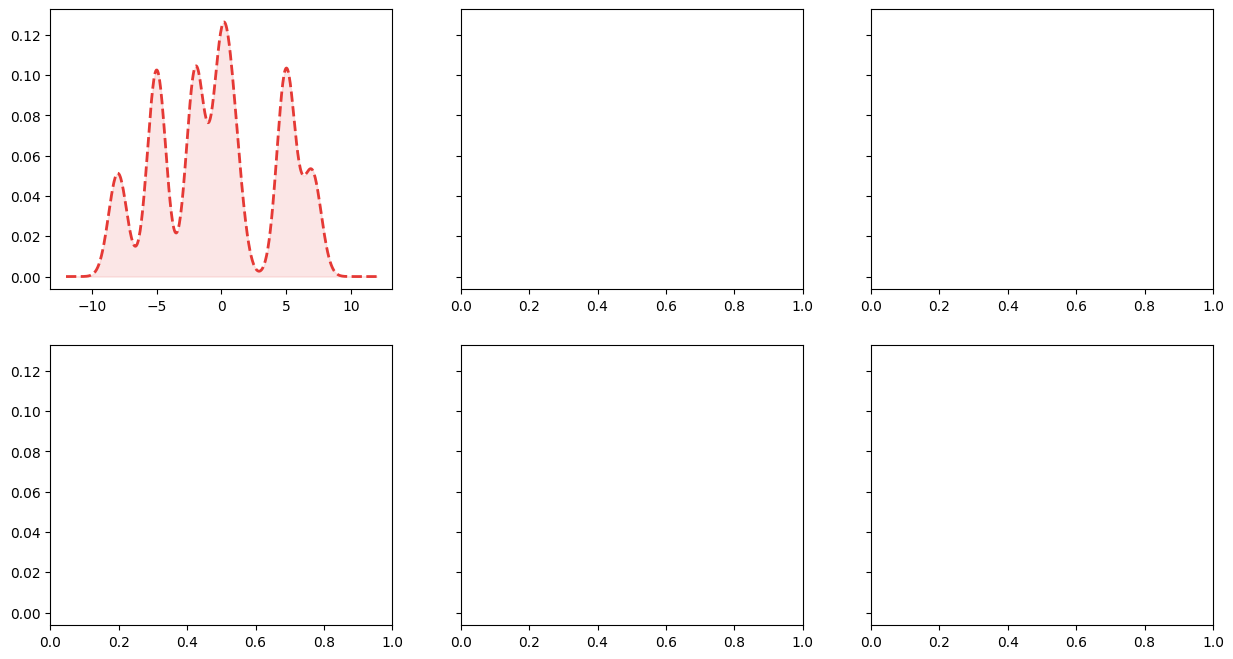

In [232]:


# ============================================================
# 4. Plot: 2x3 grid, KDE of samples vs analytical Q
# ============================================================
# fig, axes = plt.subplots(2,3, figsize=(15, 8), sharey=False)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes_flat = axes.flatten()   # fix: flatten 2D axes array
# fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, zeta in zip(axes_flat, ZETA_VALUES):
    samples = cdms_samples[zeta]


    # Analytical Q
    ax.plot(x_grid, analytical_Q[zeta],
            color="#E53935", lw=2, linestyle='--',
            label=r"Analytical $\mathcal{Q}_\beta$")
    ax.fill_between(x_grid, analytical_Q[zeta],
                    alpha=0.12, color="#E53935")

    # KDE of sampled x's
    if len(samples) > 1 and np.std(samples) > 1e-6:
        ax.hist(samples, bins=50,
                # 'auto',
                density=True,
        color="#1E88E5", alpha=0.6, edgecolor="white", label="Sampled $x$")
    else:
        # single sample or degenerate: just draw a vertical line
        ax.axvline(samples[0], color="#1E88E5", lw=2, label="Sampled $x$")

    # Mark x*
    ax.axvline(x_star.item(), color='k', linestyle=':', lw=1.5,
               label=f"$x^*={x_star.item()}$")

    ax.set_title(rf"$\beta = {zeta}$", fontsize=14)
    ax.set_xlabel("$x$", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_xlim(x_grid[0], x_grid[-1])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    r"CDMS: $\mathcal{Q}_\beta(x) \propto \mathcal{P}(x)\,e^{-\beta\,\mathcal{L}(x)}$"
    r" — prior ($\beta=0$) $\to$ optimization ($\beta\to\infty$)",
    fontsize=13
)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_CDMS_beta_sweep.pdf"),
            bbox_inches='tight')
plt.show()
print("CDMS plot saved.")

# Plots

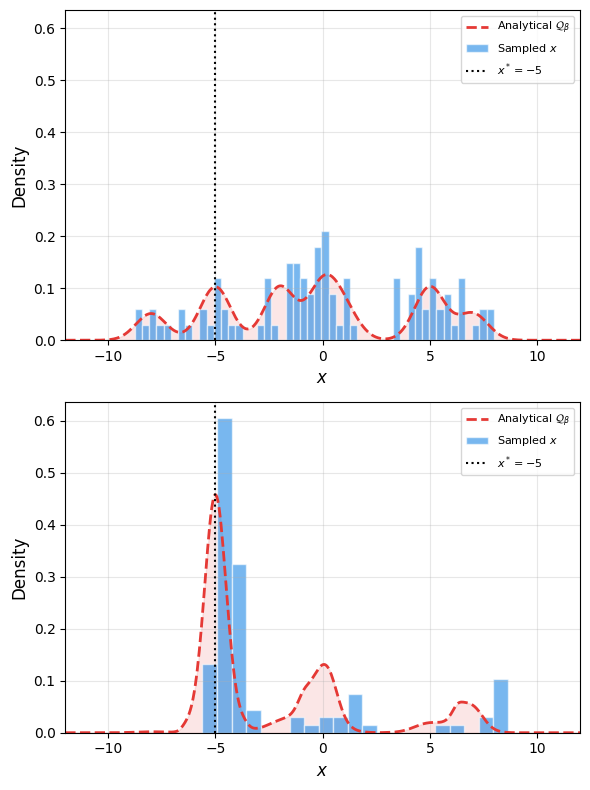

CDMS plot saved.


In [222]:
zeta_values = [k for k in cdms_samples.keys() if k in (0, 0.0, 4, 4.0)]
n = 2
fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharey=True)
axes_flat = axes.flatten()

for ax, zeta in zip(axes_flat, zeta_values):
    samples = cdms_samples[zeta]

    ax.plot(x_grid, analytical_Q[zeta],
            color="#E53935", lw=2, linestyle='--',
            label=r"Analytical $\mathcal{Q}_\beta$")
    ax.fill_between(x_grid, analytical_Q[zeta],
                    alpha=0.12, color="#E53935")

    if len(samples) > 1 and np.std(samples) > 1e-6:
        ax.hist(samples, bins=50, density=True,
                color="#1E88E5", alpha=0.6, edgecolor="white", label="Sampled $x$")
    else:
        ax.axvline(samples[0], color="#1E88E5", lw=2, label="Sampled $x$")

    ax.axvline(x_star.item(), color='k', linestyle=':', lw=1.5,
               label=f"$x^*={x_star.item()}$")

    # ax.set_title(rf"$\beta = {zeta}$", fontsize=14)
    ax.set_xlabel("$x$", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_xlim(x_grid[0], x_grid[-1])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_CDMS_beta_sweep.pdf"),
            bbox_inches='tight')
plt.show()
print("CDMS plot saved.")

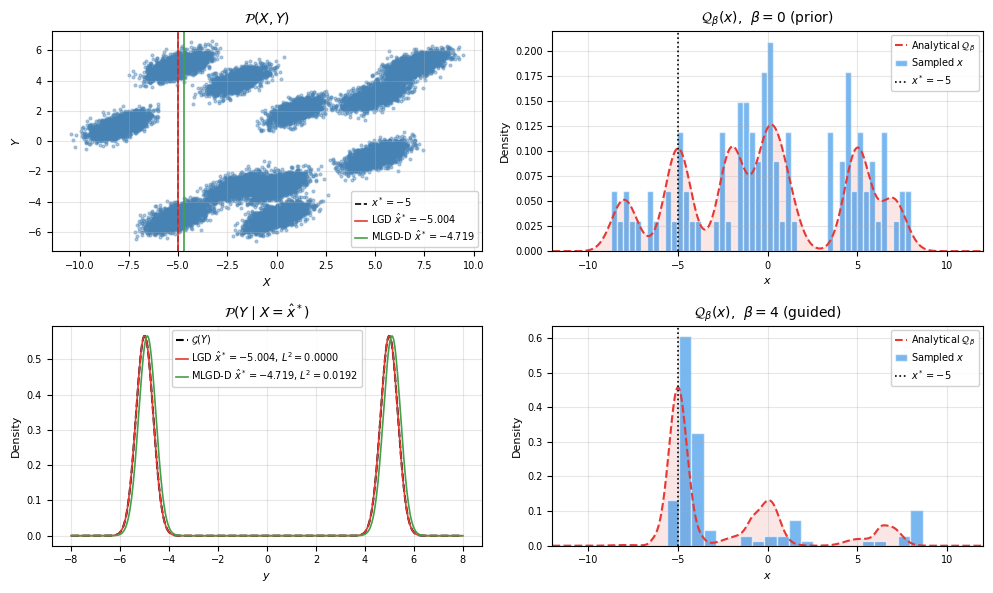

Plot saved.


In [244]:
plt.rcParams.update({
    'font.size':        9,
    'axes.titlesize':   10,
    'axes.labelsize':   8,
    'xtick.labelsize':  7,
    'ytick.labelsize':  7,
    'legend.fontsize':  7,
})

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

# ── Load results ───────────────────────────────────────────────────────────
results_path = '/content/conditional-matching-paper/simulations/results/2D_cond_1D/2D_cond_1D_results_seed42.json'
cdms_path    = '/content/conditional-matching-paper/simulations/results/2D_cond_1D/2D_cond_1D_CDMS_samples.json'

with open(results_path, 'r') as f:
    results = json.load(f)

with open(cdms_path, 'r') as f:
    cdms_raw = json.load(f)

cdms_samples = {float(v['zeta']): np.array(v['samples']) for k, v in cdms_raw.items()}

# ── Reconstruct lists from results ────────────────────────────────────────
l2_gmm_LGD_list   = results['LGD']['l2_gmm']
lgd_times         = results['LGD']['times']
best_x_t_LGD_list = [torch.tensor(x) for x in results['LGD']['x_pred']]

l2_gmm_LGD_CM_list   = results['LGD-CM']['l2_gmm']
lgd_cm_times         = results['LGD-CM']['times']
best_x_t_LGD_CM_list = [torch.tensor(x) for x in results['LGD-CM']['x_pred']]

x_star = torch.tensor(results['meta']['x_star'])

# ── Best x per method ──────────────────────────────────────────────────────
best_idx_lgd    = int(np.argmin(l2_gmm_LGD_list))
best_idx_lgd_cm = int(np.argmin(l2_gmm_LGD_CM_list))

best_x_lgd    = best_x_t_LGD_list[best_idx_lgd].float().view(-1).cpu()
best_x_lgd_cm = best_x_t_LGD_CM_list[best_idx_lgd_cm].float().view(-1).cpu()

# ── Conditional PDFs ───────────────────────────────────────────────────────
y_grid = torch.linspace(-8, 8, 500)

def cond_pdf(x_val):
    mu_c, Sig_c = dist_utils.compute_conditionals(mu_list, Sigma_list, x_val)
    w_c         = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_val)
    pdf = sum(
        w * torch.exp(-0.5 * ((y_grid - m) ** 2) / s) / (2 * torch.pi * s).sqrt()
        for w, m, s in zip(w_c, mu_c, Sig_c)
    )
    return pdf.numpy().squeeze()

pdf_gt     = cond_pdf(x_star.float())
pdf_lgd    = cond_pdf(best_x_lgd)
pdf_lgd_cm = cond_pdf(best_x_lgd_cm)

# ── CDMS zeta values ───────────────────────────────────────────────────────
zeta_values = [k for k in cdms_samples.keys() if k in (0, 0.0, 4, 4.0)]

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
legend_kw = dict(fontsize=7, framealpha=0.9,
                 handlelength=1.2, borderpad=0.4,
                 labelspacing=0.3, handletextpad=0.4,
                 borderaxespad=0.4)

# ── TOP LEFT: P(X,Y) scatter ───────────────────────────────────────────────
ax = axes[0, 0]
xh_cpu = X.detach().cpu().numpy()
ax.scatter(xh_cpu[:, 0], xh_cpu[:, 1], alpha=0.4, s=4, color='steelblue')
ax.axvline(x_star.item(),        color='k',       linestyle='--', lw=1.2,
           label=f"$x^*={x_star.item()}$")
ax.axvline(best_x_lgd.item(),    color='#E53935', linestyle='-',  lw=1.2,
           label=rf"LGD $\hat{{x}}^*={best_x_lgd.item():.3f}$")
ax.axvline(best_x_lgd_cm.item(), color='#43A047', linestyle='-',  lw=1.2,
           label=rf"MLGD-D $\hat{{x}}^*={best_x_lgd_cm.item():.3f}$")
ax.set_title(r"$\mathcal{P}(X, Y)$")
ax.set_xlabel("$X$"); ax.set_ylabel("$Y$")
ax.legend(**legend_kw); ax.grid(True, alpha=0.3)

# ── BOTTOM LEFT: P(Y|X=x*) ────────────────────────────────────────────────
ax = axes[1, 0]
y_np = y_grid.numpy()
ax.plot(y_np, pdf_gt,     color='k',       linestyle='--', lw=1.5,
        label=r"$\mathcal{G}(Y)$")
ax.plot(y_np, pdf_lgd,    color='#E53935', linestyle='-',  lw=1.2,
        label=rf"LGD $\hat{{x}}^*={best_x_lgd.item():.3f}$, "
              rf"$L^2={l2_gmm_LGD_list[best_idx_lgd]:.4f}$")
ax.plot(y_np, pdf_lgd_cm, color='#43A047', linestyle='-',  lw=1.2,
        label=rf"MLGD-D $\hat{{x}}^*={best_x_lgd_cm.item():.3f}$, "
              rf"$L^2={l2_gmm_LGD_CM_list[best_idx_lgd_cm]:.4f}$")
ax.set_title(r"$\mathcal{P}(Y \mid X = \hat{x}^*)$")
ax.set_xlabel("$y$"); ax.set_ylabel("Density")
ax.legend(**legend_kw); ax.grid(True, alpha=0.3)

# ── RIGHT COLUMN: CDMS beta=0 (top) and beta=4 (bottom) ───────────────────
right_titles = [
    r"$\mathcal{Q}_\beta(x)$,  $\beta=0$ (prior)",
    r"$\mathcal{Q}_\beta(x)$,  $\beta=4$ (guided)",
]
for ax, zeta, title in zip([axes[0, 1], axes[1, 1]], zeta_values, right_titles):
    samples = np.atleast_1d(cdms_samples[zeta])

    ax.plot(x_grid, analytical_Q[zeta],
            color="#E53935", lw=1.5, linestyle='--',
            label=r"Analytical $\mathcal{Q}_\beta$")
    ax.fill_between(x_grid, analytical_Q[zeta],
                    alpha=0.12, color="#E53935")

    if len(samples) > 1 and np.std(samples) > 1e-6:
        ax.hist(samples, bins=50, density=True,
                color="#1E88E5", alpha=0.6, edgecolor="white",
                label=r"Sampled $x$")
    else:
        ax.axvline(samples[0], color="#1E88E5", lw=1.5, label=r"Sampled $x$")

    ax.axvline(x_star.item(), color='k', linestyle=':', lw=1.2,
               label=f"$x^*={x_star.item()}$")

    ax.set_title(title)
    ax.set_xlabel("$x$"); ax.set_ylabel("Density")
    ax.set_xlim(x_grid[0], x_grid[-1])
    ax.legend(**legend_kw); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_2DCOND1D.pdf"),
            bbox_inches='tight', dpi=300)
plt.show()
print("Plot saved.")